#Numpy Advanced

In [1]:
# All imports for today's lecture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Set a seed for reproducibility
np.random.seed(42)

print(f"NumPy version: {np.__version__}")
print("All libraries loaded! Ready for Day 2.")

NumPy version: 2.0.2
All libraries loaded! Ready for Day 2.


```
 Advanced Statistics

    ┌──────────────────────────────────────────────────────────────┐
    │ Median, percentiles         │ np.median(), np.percentile()  │
    │ Variance & standard dev     │ np.var(), np.std()            │
    │ Correlation                 │ np.corrcoef()                 │
    │ Linear algebra              │ np.linalg.det(), inv(), solve()│
    │ Dates & time series         │ np.datetime64, np.timedelta64 │
    │ Images as arrays            │ 2D/3D arrays = pixels         │
    │ NumPy + Pandas workflows    │ .values, pd.DataFrame()       │
    │ Hypothesis testing          │ scipy.stats (intro)           │
    └──────────────────────────────────────────────────────────────┘
```

In [2]:
# Load dataset for today's examples
tips = sns.load_dataset('tips')
total_bills = tips['total_bill'].values  #haciendo .values genera el array 1D
tip_amounts = tips['tip'].values

print(f"Shape: {tips.shape}")
print(f"total_bills: {total_bills[:5]}  (first 5)")
print(f"tip_amounts: {tip_amounts[:5]}  (first 5)")

Shape: (244, 7)
total_bills: [16.99 10.34 21.01 23.68 24.59]  (first 5)
tip_amounts: [1.01 1.66 3.5  3.31 3.61]  (first 5)


In [3]:
# Warm-Up - Boolean indexing
small_tips = tip_amounts[tip_amounts < 2.0]  # tips less than $2.00
print(f"Count: {len(small_tips)}")
print(f"Mean: ${small_tips.mean():.2f}")

Count: 45
Mean: $1.50


## Median - The Outlier-Resistant Average

```
    ┌────────────────────────────────────────────────────────────┐
    │  mean ≈ median  →  Data is roughly symmetric              │
    │  mean > median  →  Data is right-skewed (long right tail) │
    │  mean < median  →  Data is left-skewed (long left tail)   │
    └────────────────────────────────────────────────────────────┘
```

Mean total bill:   $19.79
Median total bill: $17.80
Difference:        $1.99

Mean > Median → right-skewed (some big bills pull the mean up)


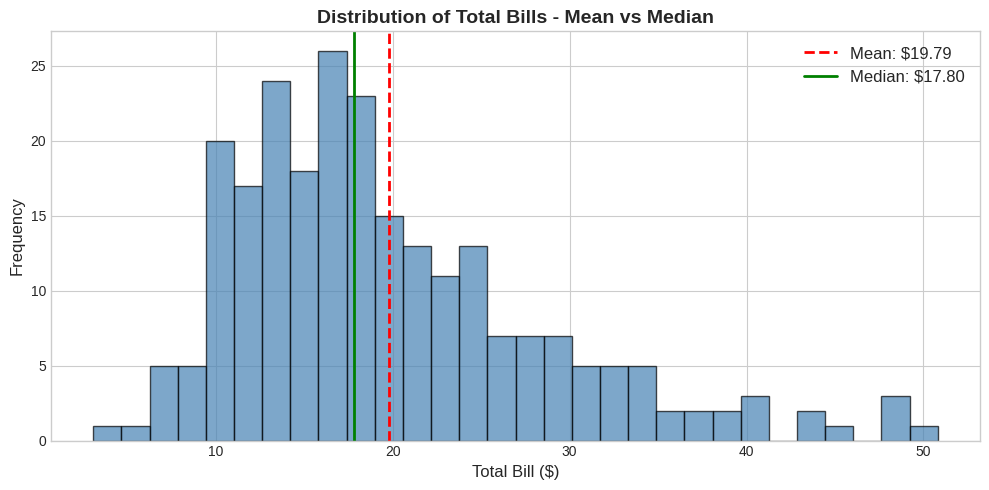

In [4]:
# Median np.median()

mean_bill = np.mean(total_bills)
median_bill = np.median(total_bills)

print(f"Mean total bill:   ${mean_bill:.2f}")
print(f"Median total bill: ${median_bill:.2f}")
print(f"Difference:        ${mean_bill - median_bill:.2f}")
print()
print(f"Mean > Median → right-skewed (some big bills pull the mean up)")

# Visualize it
plt.figure(figsize=(10, 5))
plt.hist(total_bills, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(mean_bill, color='red', linewidth=2, linestyle='--', label=f'Mean: ${mean_bill:.2f}')
plt.axvline(median_bill, color='green', linewidth=2, linestyle='-', label=f'Median: ${median_bill:.2f}')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Total Bills - Mean vs Median', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Percentiles - Dividing Data into Ranks

```
PERCENTILES AND QUARTILES:

    0%     25%      50%      75%      100%
    |------Q1-------Q2-------Q3-------|
    |   Bottom    Middle     Top      |
    |   quarter   (median)   quarter  |

              IQR = Q3 - Q1
              (interquartile range)

    np.percentile(arr, 25)   → Q1
    np.percentile(arr, 50)   → Q2 = Median
    np.percentile(arr, 75)   → Q3
    np.percentile(arr, [25, 50, 75])  → all three at once
```

In [5]:
# percentiles np.percentile()
q1 = np.percentile(total_bills, 25)
q2 = np.percentile(total_bills, 50)  # Same as median!
q3 = np.percentile(total_bills, 75)
iqr = q3 - q1

print(f"Q1 (25th percentile): ${q1:.2f}")
print(f"Q2 (50th percentile): ${q2:.2f}  ← same as median: ${np.median(total_bills):.2f}")
print(f"Q3 (75th percentile): ${q3:.2f}")
print(f"IQR (Q3 - Q1):        ${iqr:.2f}")
print()
print(f"The middle 50% of bills fall between ${q1:.2f} and ${q3:.2f}")

Q1 (25th percentile): $13.35
Q2 (50th percentile): $17.80  ← same as median: $17.80
Q3 (75th percentile): $24.13
IQR (Q3 - Q1):        $10.78

The middle 50% of bills fall between $13.35 and $24.13


## Variance & Standard Deviation

```
THE SPREAD PROBLEM:

    Class A scores: [72, 74, 75, 76, 78]     mean = 75
    Class B scores: [30, 55, 75, 95, 100]     mean = 71

    Same-ish averages, VERY different stories!

    VARIANCE: Average of squared distances from mean
    ────────
    Step 1: Find distance from mean for each value
    Step 2: Square each distance (makes all positive)
    Step 3: Average the squared distances

    STANDARD DEVIATION: Square root of variance
    ──────────────────
    → Back to original units!
    → "On average, values are THIS far from the mean"

    np.var(arr)  → variance
    np.std(arr)  → standard deviation = sqrt(variance)

    NEW TOOL: np.random.normal(loc, scale, size)
    ─────────────────────────────────────────────
    loc   = center of the bell curve (mean)
    scale = width of the bell curve (std dev)
    size  = how many numbers to generate
```

Class A (tight cluster):
  Mean: 74.2,  Std Dev: 3.5,  Variance: 12.5
  Min: 67.3,  Max: 81.3

Class B (wide spread):
  Mean: 72.3,  Std Dev: 20.1,  Variance: 405.6
  Min: 31.9,  Max: 115.8


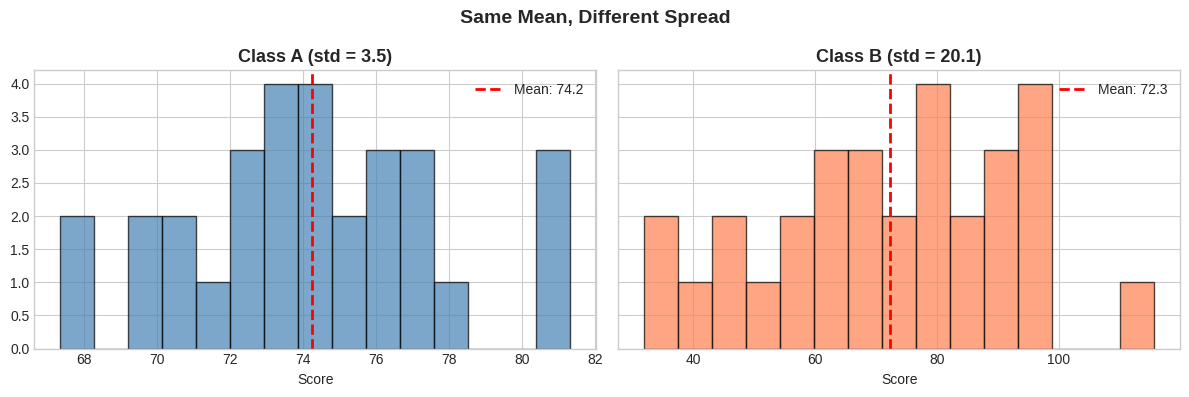

In [6]:
 # Variance & standard dev  | np.var(), np.std()

 # => np.random.normal genera una valores para una distribución normal

# Two classes, same mean, different spread
np.random.seed(42)
class_a = np.random.normal(loc=75, scale=4, size=30)    # tight cluster around 75, std=4, 30 students
class_b = np.random.normal(loc=75, scale=22, size=30)    # wide spread around 75, std=22, 30 students

print("Class A (tight cluster):")
print(f"  Mean: {class_a.mean():.1f},  Std Dev: {class_a.std():.1f},  Variance: {class_a.var():.1f}")
print(f"  Min: {class_a.min():.1f},  Max: {class_a.max():.1f}")

print("\nClass B (wide spread):")
print(f"  Mean: {class_b.mean():.1f},  Std Dev: {class_b.std():.1f},  Variance: {class_b.var():.1f}")
print(f"  Min: {class_b.min():.1f},  Max: {class_b.max():.1f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(class_a, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(class_a.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {class_a.mean():.1f}')
axes[0].set_title(f'Class A (std = {class_a.std():.1f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].legend()

axes[1].hist(class_b, bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(class_b.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {class_b.mean():.1f}')
axes[1].set_title(f'Class B (std = {class_b.std():.1f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.suptitle('Same Mean, Different Spread', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Exercise - Statistical Analysis
np.random.seed(42)
data = np.random.normal(loc=100, scale=15, size=50)  # normal distribution: mean=100, std=15, 50 values

mean_val = np.mean(data)
median_val = np.median(data)
std_val = np.std(data)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)

print(f"Mean:    {mean_val:.2f}")
print(f"Median:  {median_val:.2f}")
print(f"Std Dev: {std_val:.2f}")
print(f"Q1 (25th): {q1:.2f}")
print(f"Q3 (75th): {q3:.2f}")

Mean:    96.62
Median:  96.49
Std Dev: 13.86
Q1 (25th): 87.09
Q3 (75th): 105.04


## Correlation

```
CORRELATION COEFFICIENT (r):

    r = +1.0   Perfect positive  (one goes up, other goes up)
    r = +0.7   Strong positive
    r = +0.3   Weak positive
    r =  0.0   No linear relationship
    r = -0.3   Weak negative
    r = -0.7   Strong negative
    r = -1.0   Perfect negative  (one goes up, other goes down)

    np.corrcoef(x, y) → returns a 2x2 matrix:
    ┌─────────────────────────────┐
    │  corr(x,x)    corr(x,y)    │
    │  corr(y,x)    corr(y,y)    │
    └─────────────────────────────┘
    The value you want is [0, 1] or [1, 0]
    (corr(x,x) is always 1.0 - everything is perfectly correlated with itself!)
```

In [8]:
# Correlation between total bill and tip
corr_matrix = np.corrcoef(total_bills, tip_amounts)    # np.corrcoef(x, y) → returns a 2x2 matrix:
r = corr_matrix[0, 1]

print("Correlation matrix:")
print(corr_matrix.round(3))
print(f"\nCorrelation between bill and tip: r = {r:.3f}")
print()

if abs(r) > 0.7:
    strength = "strong"
elif abs(r) > 0.3:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if r > 0 else "negative"
print(f"Interpretation: {strength} {direction} correlation")
print("Bigger bills tend to come with bigger tips.")

Correlation matrix:
[[1.    0.676]
 [0.676 1.   ]]

Correlation between bill and tip: r = 0.676

Interpretation: moderate positive correlation
Bigger bills tend to come with bigger tips.


---

# Linear Algebra - Matrix Operations

## The Math That Powers Machine Learning

---

```
LINEAR ALGEBRA ROADMAP:

    ┌──────────────────────────────────────────────────────────────┐
    │                                                              │
    │   DETERMINANT  →  "Is my matrix healthy?"                    │
    │   np.linalg.det(A)                                           │
    │   - det ≠ 0 → matrix is invertible, data has unique info     │
    │   - det = 0 → singular matrix, redundant data                │
    │                                                              │
    │   INVERSE  →  "Undo a matrix transformation"                 │
    │   np.linalg.inv(A)                                           │
    │   - A @ A_inv = Identity matrix (like x * 1/x = 1)           │
    │   - Only exists when det ≠ 0                                 │
    │                                                              │
    │   SOLVE  →  "Find unknowns from equations"                   │
    │   np.linalg.solve(A, b)                                      │
    │   - Solves Ax = b for x                                      │
    │   - More efficient than computing the inverse                │
    │                                                              │
    │ np.linalg.det(), inv(), solve()                              │
    │                                                              │
    └──────────────────────────────────────────────────────────────┘
```

## The Determinant - Is Your Matrix Healthy?

In [9]:
# Create a 3x3 matrix
A = np.array([[6, 1, 1],
              [4, -2, 5],
              [2, 8, 7]])

print("Matrix A:")
print(A)
print()

# Calculate the determinant
det_A = np.linalg.det(A)

print(f"Determinant of A: {det_A:.2f}")
print()

if abs(det_A) > 1e-10:
    print("det != 0 → Matrix is invertible! Data has independent information.")
else:
    print("det = 0 → Matrix is SINGULAR. Columns are redundant.")

Matrix A:
[[ 6  1  1]
 [ 4 -2  5]
 [ 2  8  7]]

Determinant of A: -306.00

det != 0 → Matrix is invertible! Data has independent information.


In [10]:
# Find the inverse
A_inv = np.linalg.inv(A)

print("Matrix A:")
print(A)
print()
print("Inverse of A:")
print(A_inv.round(4))
print()

# Verify: A @ A_inv should equal the identity matrix
product = A @ A_inv
print("A @ A_inv (should be identity):")
print(product.round(10))
print()
print(f"Is it the identity? {np.allclose(product, np.eye(3))}")       #np.allclose(A, B)  --->   # Check if arrays are ~equal

Matrix A:
[[ 6  1  1]
 [ 4 -2  5]
 [ 2  8  7]]

Inverse of A:
[[ 0.1765 -0.0033 -0.0229]
 [ 0.0588 -0.1307  0.085 ]
 [-0.1176  0.1503  0.0523]]

A @ A_inv (should be identity):
[[ 1.  0.  0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Is it the identity? True


In [11]:
# System of equations:
# 4x + 7y = 27
# 2x + 6y = 16

# Express as Ax = b
A = np.array([[4, 7],
              [2, 6]])
b = np.array([27, 16])

# Check if solvable
print(f"Determinant: {np.linalg.det(A):.2f} (non-zero = solvable)")
print()

# Method 1: Using inverse (educational)
x_inv = np.linalg.inv(A) @ b
print(f"Method 1 (inverse):  x = {x_inv[0]:.4f}, y = {x_inv[1]:.4f}")

# Method 2: Using solve (preferred - faster, more stable)        #usar este, se prefiere
x_solve = np.linalg.solve(A, b)
print(f"Method 2 (solve):    x = {x_solve[0]:.4f}, y = {x_solve[1]:.4f}")

# Verify
print(f"\nVerification: 4({x_solve[0]:.2f}) + 7({x_solve[1]:.2f}) = {4*x_solve[0] + 7*x_solve[1]:.2f} (should be 27)")
print(f"Verification: 2({x_solve[0]:.2f}) + 6({x_solve[1]:.2f}) = {2*x_solve[0] + 6*x_solve[1]:.2f} (should be 16)")

Determinant: 10.00 (non-zero = solvable)

Method 1 (inverse):  x = 5.0000, y = 1.0000
Method 2 (solve):    x = 5.0000, y = 1.0000

Verification: 4(5.00) + 7(1.00) = 27.00 (should be 27)
Verification: 2(5.00) + 6(1.00) = 16.00 (should be 16)


```
WHEN TO USE WHAT:
    ┌────────────────────────────────────────────────────────────┐
    │  np.linalg.det(A)    │ Check if matrix is invertible      │
    │  np.linalg.inv(A)    │ Educational / understanding        │
    │  np.linalg.solve(A,b)│ Actually solving equations (prefer) │
    └────────────────────────────────────────────────────────────┘

    Why prefer solve()?
    - Faster (doesn't compute full inverse)
    - More numerically stable
    - One step instead of two
```

---

#Array Comparisons & Element-wise Operations

## Comparing Arrays Side by Side

---

## Element-wise Array Comparison

```
COMPARING TWO ARRAYS:

    array_1 = [10, 25, 15, 30, 20]
    array_2 = [12, 20, 18, 28, 22]

    array_1 > array_2  →  [False, True, False, True, False]
                             ↓     ↓      ↓     ↓     ↓
                           10<12  25>20  15<18  30>28  20<22

    USEFUL OPERATIONS ON THE RESULT:
    ─────────────────────────────────
    .sum()     → count of True values (how many elements are greater)
    .mean()    → proportion of True values
    np.where() → choose values based on condition
```

In [12]:
# Comparing two arrays element-wise
store_sales_jan = np.array([150, 230, 180, 310, 195, 275, 140, 260])
store_sales_feb = np.array([165, 210, 195, 290, 220, 280, 155, 240])
store_names = ['Store A', 'Store B', 'Store C', 'Store D',
               'Store E', 'Store F', 'Store G', 'Store H']

# Element-wise comparison
jan_higher = store_sales_jan > store_sales_feb

print("January sales: ", store_sales_jan)
print("February sales:", store_sales_feb)
print("Jan > Feb?     ", jan_higher)
print()
print(f"Stores where January was higher: {jan_higher.sum()} out of {len(jan_higher)}")
print(f"Proportion: {jan_higher.mean():.0%}")
print()

# Which specific stores?
for name, jan, feb, better in zip(store_names, store_sales_jan, store_sales_feb, jan_higher):
    status = "Jan wins" if better else "Feb wins"
    print(f"  {name}: Jan=${jan}, Feb=${feb} → {status}")

January sales:  [150 230 180 310 195 275 140 260]
February sales: [165 210 195 290 220 280 155 240]
Jan > Feb?      [False  True False  True False False False  True]

Stores where January was higher: 3 out of 8
Proportion: 38%

  Store A: Jan=$150, Feb=$165 → Feb wins
  Store B: Jan=$230, Feb=$210 → Jan wins
  Store C: Jan=$180, Feb=$195 → Feb wins
  Store D: Jan=$310, Feb=$290 → Jan wins
  Store E: Jan=$195, Feb=$220 → Feb wins
  Store F: Jan=$275, Feb=$280 → Feb wins
  Store G: Jan=$140, Feb=$155 → Feb wins
  Store H: Jan=$260, Feb=$240 → Jan wins


In [13]:
# np.where() - if-else for arrays
# Syntax: np.where(condition, value_if_true, value_if_false)
labels = np.where(jan_higher, "Jan Higher", "Feb Higher")
print("Store performance labels:", labels)
print()

# Calculate the change
change = store_sales_feb - store_sales_jan
print("Sales change (Feb - Jan):", change)
print("Positive changes (improvements):", change[change > 0])
print("Negative changes (declines):    ", change[change < 0])

Store performance labels: ['Feb Higher' 'Jan Higher' 'Feb Higher' 'Jan Higher' 'Feb Higher'
 'Feb Higher' 'Feb Higher' 'Jan Higher']

Sales change (Feb - Jan): [ 15 -20  15 -20  25   5  15 -20]
Positive changes (improvements): [15 15 25  5 15]
Negative changes (declines):     [-20 -20 -20]


---

# Working with Dates & Time Series

## Because Real-World Data Lives on a Timeline

---

## Key Concept: NumPy Dates

```
DATE TYPES IN NUMPY:

    datetime64  →  A specific point in time
    ──────────
    np.datetime64('2023-01-15')        → January 15, 2023
    np.datetime64('2023-01-15', 'M')   → January 2023 (month precision)

    timedelta64  →  A duration / difference
    ───────────
    np.timedelta64(30, 'D')            → 30 days
    np.timedelta64(2, 'W')             → 2 weeks

    ARITHMETIC:
    date2 - date1                      → timedelta (duration)
    date + timedelta                   → new date
    np.arange(start_date, end_date)    → array of dates!
```

In [14]:
# Dates & time series  --> np.datetime64, np.timedelta64

#default format 'YYYY-MM-DD'

 # Date basics
date1 = np.datetime64('2023-01-15')  # January 15, 2023
date2 = np.datetime64('2023-03-20')  # March 20, 2023

print(f"Date 1: {date1}")
print(f"Date 2: {date2}")
print()

# Date arithmetic
diff = date2 - date1
print(f"Difference: {diff}")
print()

# Add a duration
future = date1 + np.timedelta64(30, 'D')  # 30 days
print(f"30 days after {date1}: {future}")
print()

# Creating Date Arrays
# All days in January 2023
january_2023 = np.arange('2023-01-01', '2023-02-01', dtype='datetime64[D]')  # hint: np.arange with datetime64[D]
print(f"All days in January 2023 ({len(january_2023)} days):")
print(january_2023)
print()

# All weeks in 2023
weeks_2023 = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[W]')  # hint: np.arange with datetime64[W]
print(f"All weeks in 2023 ({len(weeks_2023)} weeks):")
print(weeks_2023[:10], "...")  #muestra las primeras 10


Date 1: 2023-01-15
Date 2: 2023-03-20

Difference: 64 days

30 days after 2023-01-15: 2023-02-14

All days in January 2023 (31 days):
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31']

All weeks in 2023 (52 weeks):
['2022-12-29' '2023-01-05' '2023-01-12' '2023-01-19' '2023-01-26'
 '2023-02-02' '2023-02-09' '2023-02-16' '2023-02-23' '2023-03-02'] ...


In [15]:
# Convert dates to strings and change format
january_strings = january_2023.astype(str)  # convert january_2023 to strings
print("Default format (YYYY-MM-DD):")
print(january_strings[:5])
print()

# Convert to YYYY/MM/DD format
formatted = np.char.replace(january_strings, '-', '/')  # replace '-' with '/'
print("Converted format (YYYY/MM/DD):")
print(formatted[:5])
print()

# Date precision conversion
months_2023 = january_2023.astype('datetime64[M]')  #imprime el mes  YYYY-MM
print(f"Month precision: {months_2023[0]}")
years_2023 = january_2023.astype('datetime64[Y]')   #imprime el año  YYYY
print(f"Year precision:  {years_2023[0]}")

Default format (YYYY-MM-DD):
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05']

Converted format (YYYY/MM/DD):
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05']

Month precision: 2023-01
Year precision:  2023


In [16]:
#Generating Time Series Data

# Generate a year of daily stock price data
np.random.seed(42)

dates_2023 = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')
daily_changes = np.random.normal(0, 2, len(dates_2023))  # random daily changes (mean=0, std=2)
# [+0.5, -1.2, +0.3...]
stock_prices = 100 + np.cumsum(daily_changes)  # start at $100, accumulate changes

print(f"Generated {len(dates_2023)} days of stock price data")
print(f"Start price: ${stock_prices[0]:.2f}")
print(f"End price:   ${stock_prices[-1]:.2f}")
print(f"Min price:   ${stock_prices.min():.2f}")
print(f"Max price:   ${stock_prices.max():.2f}")

Generated 365 days of stock price data
Start price: $100.99
End price:   $107.26
Min price:   $72.95
Max price:   $113.58


In [17]:
# Slicing Time Series by Quarter

# Define quarter boundaries
quarters = [
    ("Q1: Jan-Mar", '2023-01-01', '2023-04-01'),
    ("Q2: Apr-Jun", '2023-04-01', '2023-07-01'),
    ("Q3: Jul-Sep", '2023-07-01', '2023-10-01'),
    ("Q4: Oct-Dec", '2023-10-01', '2024-01-01'),
]

print("Quarterly Analysis:")
print("-" * 55)
for name, start, end in quarters:
    mask = (dates_2023 >= np.datetime64(start)) & (dates_2023 <= np.datetime64(end))  # boolean mask: dates >= start AND dates < end
    q_prices = stock_prices[mask]
    print(f"  {name}: Mean=${q_prices.mean():.2f}, "
          f"Min=${q_prices.min():.2f}, Max=${q_prices.max():.2f}")


Quarterly Analysis:
-------------------------------------------------------
  Q1: Jan-Mar: Mean=$87.82, Min=$75.51, Max=$108.96
  Q2: Apr-Jun: Mean=$79.74, Min=$72.95, Max=$93.28
  Q3: Jul-Sep: Mean=$95.21, Min=$83.69, Max=$105.28
  Q4: Oct-Dec: Mean=$101.55, Min=$90.13, Max=$113.58


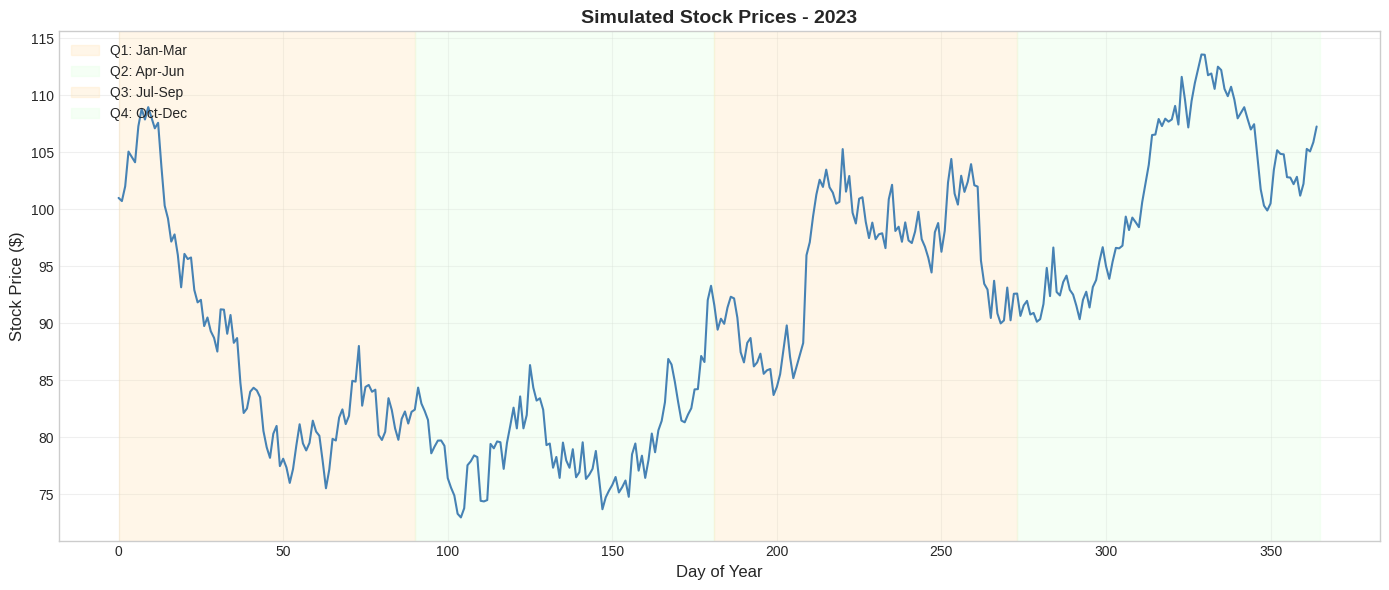

In [18]:
# Visualizing Time Series

# Plot the full year with quarter highlights
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(dates_2023)), stock_prices, linewidth=1.5, color='steelblue')

# Highlight quarters with alternating background colors
colors = ['#FFE4B5', '#E0FFE0', '#FFE4B5', '#E0FFE0']
start_idx = 0
for i, (name, start, end) in enumerate(quarters):
    mask = (dates_2023 >= np.datetime64(start)) & (dates_2023 < np.datetime64(end))
    end_idx = start_idx + mask.sum()
    ax.axvspan(start_idx, end_idx, alpha=0.3, color=colors[i], label=name)
    start_idx = end_idx

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('Stock Price ($)', fontsize=12)
ax.set_title('Simulated Stock Prices - 2023', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Concept: Pixels as Numbers

```
IMAGE REPRESENTATION:

    GRAYSCALE (2D array):
    ┌───┬───┬───┬───┬───┐
    │ 0 │ 0 │255│ 0 │ 0 │     0   = black
    ├───┼───┼───┼───┼───┤     128 = gray
    │ 0 │255│ 0 │255│ 0 │     255 = white
    ├───┼───┼───┼───┼───┤
    │255│ 0 │ 0 │ 0 │255│     Shape: (height, width)
    ├───┼───┼───┼───┼───┤     Dtype: uint8 (0-255)
    │ 0 │255│ 0 │255│ 0 │
    ├───┼───┼───┼───┼───┤
    │ 0 │ 0 │255│ 0 │ 0 │
    └───┴───┴───┴───┴───┘
    → This draws an X pattern!

    COLOR / RGB (3D array):
    ┌─────────────────────┐
    │  [R, G, B]          │     Each pixel has 3 values
    │  [255, 0, 0] = red  │     Shape: (height, width, 3)
    │  [0, 255, 0] = green│
    │  [0, 0, 255] = blue │
    │  [255,255,255]= white│
    └─────────────────────┘
```

5x5 Grayscale Image (cross pattern):
[[  0   0 255   0   0]
 [  0   0 255   0   0]
 [255 255 255 255 255]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]

Shape: (5, 5)
Dtype: uint8


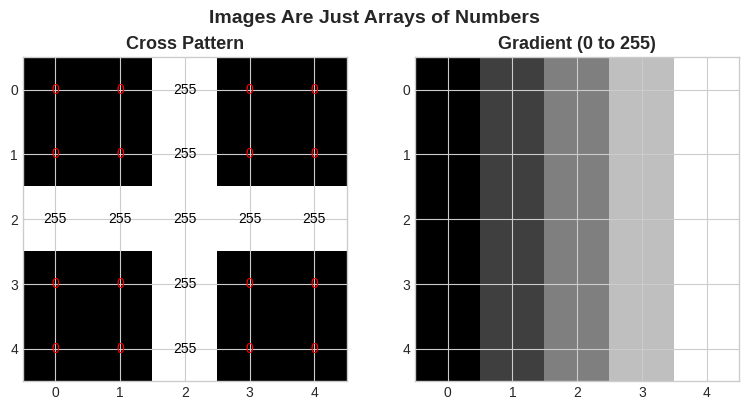

In [19]:
# Create a 5x5 grayscale image - a cross/plus pattern
cross = np.zeros((5, 5), dtype=np.uint8)  # 5x5 array of zeros, dtype=np.uint8

# Draw a cross: fill middle row and middle column with white
cross[2, :] = 255     # middle row = 255
cross[:, 2] = 255     # middle column = 255

print("5x5 Grayscale Image (cross pattern):")
print(cross)
print(f"\nShape: {cross.shape}")
print(f"Dtype: {cross.dtype}")

# Display it
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(cross, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Cross Pattern', fontsize=13, fontweight='bold')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, str(cross[i, j]), ha='center', va='center',
                     color='red' if cross[i, j] == 0 else 'black', fontsize=10)
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))

# Also show a gradient
gradient = np.linspace(0, 255, 5).astype(np.uint8)
gradient_img = np.tile(gradient, (5, 1))
axes[1].imshow(gradient_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Gradient (0 to 255)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))

plt.suptitle('Images Are Just Arrays of Numbers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

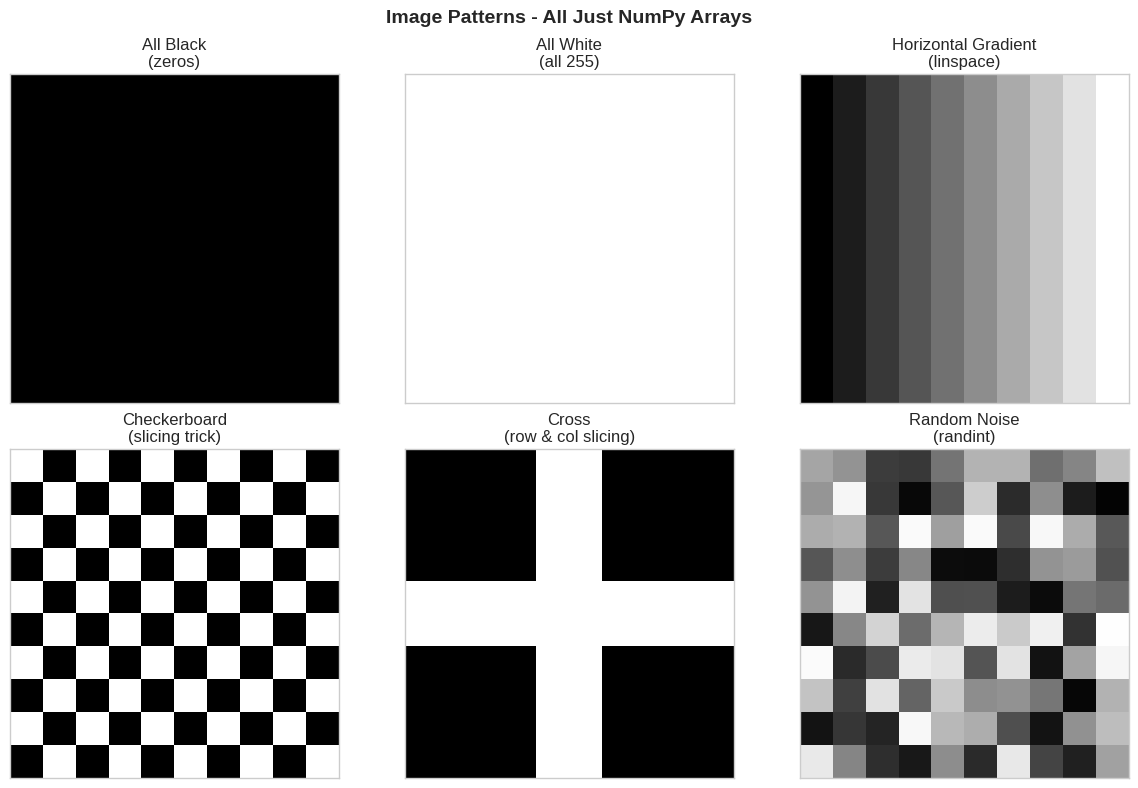

In [20]:
# Gallery of simple patterns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# 1. All black
black = np.zeros((10, 10), dtype=np.uint8)
axes[0, 0].imshow(black, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('All Black\n(zeros)')

# 2. All white
white = np.full((10, 10), 255, dtype=np.uint8)
axes[0, 1].imshow(white, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('All White\n(all 255)')

# 3. Horizontal gradient
h_gradient = np.tile(np.linspace(0, 255, 10).astype(np.uint8), (10, 1))
axes[0, 2].imshow(h_gradient, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Horizontal Gradient\n(linspace)')

# 4. Checkerboard
checker = np.zeros((10, 10), dtype=np.uint8)
checker[::2, ::2] = 255
checker[1::2, 1::2] = 255
axes[1, 0].imshow(checker, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Checkerboard\n(slicing trick)')

# 5. Cross
cross_10 = np.zeros((10, 10), dtype=np.uint8)
cross_10[4:6, :] = 255
cross_10[:, 4:6] = 255
axes[1, 1].imshow(cross_10, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Cross\n(row & col slicing)')

# 6. Random noise
noise = np.random.randint(0, 256, (10, 10), dtype=np.uint8)
axes[1, 2].imshow(noise, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Random Noise\n(randint)')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Image Patterns - All Just NumPy Arrays', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Quick Reference - Key Patterns

```python
# ADVANCED STATISTICS
np.median(arr)                    # Median (robust to outliers)
np.percentile(arr, [25, 50, 75]) # Quartiles
np.var(arr)                       # Variance
np.std(arr)                       # Standard deviation
np.corrcoef(x, y)                # Correlation matrix (value at [0,1])

# LINEAR ALGEBRA
np.linalg.det(A)                 # Determinant (0 = singular)
np.linalg.inv(A)                 # Matrix inverse
np.linalg.solve(A, b)           # Solve Ax = b (preferred over inv)
np.allclose(A, B)               # Check if arrays are ~equal

# ARRAY COMPARISON
arr1 > arr2                      # Element-wise comparison → boolean array
(arr1 > arr2).sum()             # Count where condition is True
np.where(condition, if_true, if_false)  # Array if-else

# DATES & TIME SERIES
np.datetime64('2023-01-15')              # Single date
np.timedelta64(30, 'D')                 # Duration (30 days)
np.arange('2023-01-01', '2023-02-01',
          dtype='datetime64[D]')          # Date array
dates.astype(str)                        # Convert to strings
np.char.replace(date_strs, '-', '/')    # Format conversion

# IMAGES
np.zeros((h, w), dtype=np.uint8)        # Blank grayscale image
plt.imshow(img, cmap='gray')            # Display grayscale image
# Grayscale: shape (h, w), values 0-255
# RGB color: shape (h, w, 3), values 0-255

# NUMPY ↔ PANDAS
df.values  /  df.to_numpy()             # DataFrame → NumPy
pd.DataFrame(arr, columns=['A','B'])    # NumPy → DataFrame

# BASIC HYPOTHESIS TESTING
from scipy import stats
stats.ttest_1samp(data, expected_mean)  # One-sample / paired t-test
stats.ttest_ind(group_a, group_b)       # Independent samples t-test
# p-value < 0.05 → reject null hypothesis
```

## Practice: Image Representation

Create a **5x5 grayscale image** array and demonstrate how images are represented.
Suggestions:
- A **border** (white edges, black center)
- A **diagonal** line
- A simple **smiley face** (eyes + smile)

Display it using `plt.imshow()` with `cmap='gray'`.

Hint: Start with `np.zeros((5, 5), dtype=np.uint8)` and set specific pixels to 255.

[[  0   0   0   0   0]
 [  0 255   0 255   0]
 [  0   0   0   0   0]
 [  0 255 255 255   0]
 [  0   0   0   0   0]]

[[255 255 255 255 255]
 [255   0   0   0 255]
 [255   0   0   0 255]
 [255   0   0   0 255]
 [255 255 255 255 255]]

[[255   0   0   0   0]
 [  0 255   0   0   0]
 [  0   0 255   0   0]
 [  0   0   0 255   0]
 [  0   0   0   0 255]]


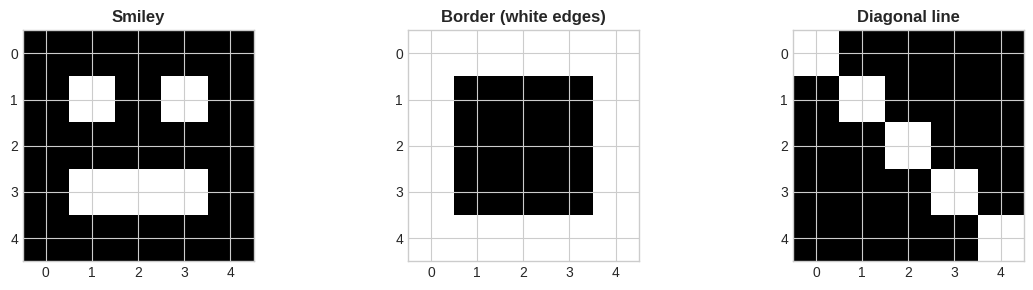

In [21]:
smiley = np.zeros((5, 5), dtype=np.uint8)

# Set pixels to 255 to draw your pattern:
#Eyes
smiley[1, 1] = 255 # left eye
smiley[1, 3] = 255 # right eye

# Smile
smiley[3, 1] = 255
smiley[3, 2] = 255
smiley[3, 3] = 255

print(smiley)
print()


img2 = np.zeros((5,5), dtype=np.uint8)
img2[0,:] = 255      # top row
img2[-1,:] = 255     # bottom row
img2[:,0] = 255      # left column
img2[:,-1] = 255     # right column
print(img2)
print()

img3 = np.zeros((5,5), dtype=np.uint8)
np.fill_diagonal(img3, 255)
# o tambien
# for i in range(5):
#     img[i,i] = 255
print(img3)


fig, axes = plt.subplots(1, 3, figsize=(12,3))

# Smiley
axes[0].imshow(smiley, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Smiley', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))

# Border
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Border (white edges)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))

# Diagonal
axes[2].imshow(img3, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Diagonal line', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(5))
axes[2].set_yticks(range(5))

plt.tight_layout()
plt.show()


---
#  NumPy + Pandas Integration & Visualization
---

```
WHEN TO USE WHAT:

    ┌───────────────────────────────────────────────────────────────┐
    │  PANDAS                          │  NUMPY                    │
    ├──────────────────────────────────┼───────────────────────────┤
    │  Labeled data (column names)     │  Pure number crunching    │
    │  Mixed types (str + int + float) │  Same-type arrays         │
    │  Groupby, merge, pivot           │  Linear algebra           │
    │  Missing value handling          │  Fast element-wise ops    │
    │  Reading CSV/Excel files         │  Image processing         │
    │  Exploratory data analysis       │  Simulations              │
    ├──────────────────────────────────┴───────────────────────────┤
    │                                                               │
    │  CONVERTING BETWEEN THEM:                                    │
    │  DataFrame → NumPy:  df.values  or  df.to_numpy()           │
    │  NumPy → DataFrame:  pd.DataFrame(array, columns=[...])     │
    │                                                               │
    └───────────────────────────────────────────────────────────────┘
```

In [22]:
# NumPy + Pandas workflows    # .values, pd.DataFrame()


# Start with pandas, extract NumPy arrays
iris = sns.load_dataset('iris')
print("Iris dataset (pandas):")
print(iris.head())
print(f"Type: {type(iris)}")
print()

# Extract numeric columns as a NumPy array
numeric_data = iris.iloc[:, :4]  # hint: .iloc[:, :4].values
print(f"As NumPy array:")
print(f"Type: {type(numeric_data)}")
print(f"Shape: {numeric_data.shape}")
print(f"First 3 rows:\n{numeric_data[:3]}")

Iris dataset (pandas):
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Type: <class 'pandas.core.frame.DataFrame'>

As NumPy array:
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (150, 4)
First 3 rows:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2


In [23]:
# Start with NumPy, build a DataFrame
np.random.seed(42)

# Generate synthetic employee data
n_employees = 50
ages = np.random.randint(22, 65, n_employees)
salaries = 30000 + ages * 800 + np.random.normal(0, 5000, n_employees)
experience = (ages - 22) * 0.7 + np.random.normal(0, 2, n_employees)
experience = np.clip(experience, 0, None)  # clip: cap values at 0 minimum (no negative experience)

# Convert to DataFrame
df = pd.DataFrame({
    'Age': ages.round(0).astype(int),
    'Salary': salaries.round(0).astype(int),
    'Experience': experience.round(1)
})

print("NumPy arrays → DataFrame:")
print(df.head(10))
print(f"\nShape: {df.shape}")

NumPy arrays → DataFrame:
   Age  Salary  Experience
0   60   76853        27.6
1   50   71947        21.9
2   36   52474        10.3
3   64   86660        30.0
4   29   67092         7.6
5   42   69568        14.4
6   60   79093        26.0
7   40   66409        13.9
8   44   60155        14.9
9   32   47684         6.3

Shape: (50, 3)


In [24]:
#netiendo que hace todo con pandas, usando df (dataframe pandas)

# Conditional selection
high_earners = df[df['Salary'] > 60000]  # filter: salary > 60000
print(f"High earners (salary > $60K): {len(high_earners)} employees")
print(high_earners.head())
print()

# Aggregation
print("Summary statistics:")
print(f"  Total salary budget: ${df['Salary'].sum():,.0f}")
print(f"  Average salary:      ${df['Salary'].mean():,.0f}")
print(f"  Average age:         {df['Age'].mean():.1f} years")
print(f"  Average experience:  {df['Experience'].mean():.1f} years")
print()

# Groupby with NumPy-powered aggregation
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 65],
                         labels=['20s', '30s', '40s', '50+'])
print("Average salary by age group:")
print(df.groupby('Age_Group', observed=True)['Salary'].mean().round(0))

High earners (salary > $60K): 30 employees
   Age  Salary  Experience
0   60   76853        27.6
1   50   71947        21.9
3   64   86660        30.0
4   29   67092         7.6
5   42   69568        14.4

Summary statistics:
  Total salary budget: $3,207,288
  Average salary:      $64,146
  Average age:         42.1 years
  Average experience:  14.1 years

Average salary by age group:
Age_Group
20s    55174.0
30s    57422.0
40s    64828.0
50+    77194.0
Name: Salary, dtype: float64


## Visualization with NumPy & Matplotlib

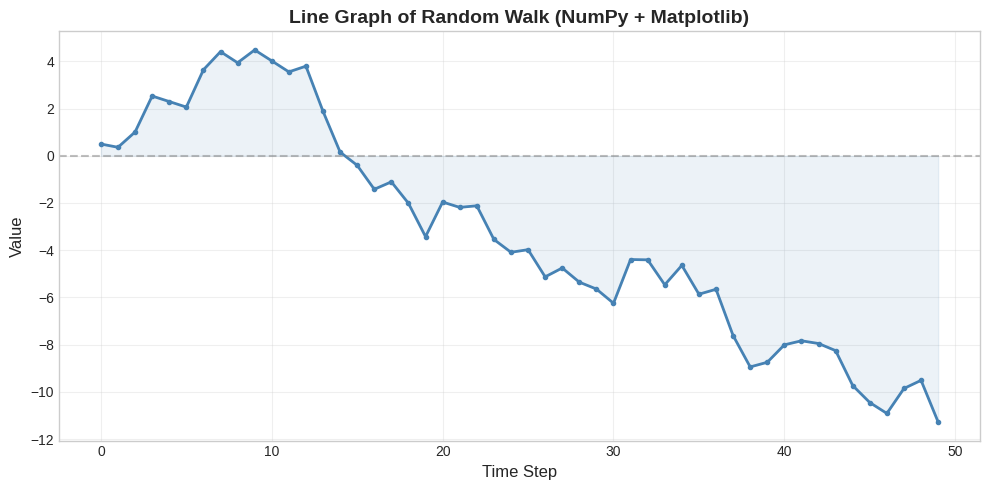

In [25]:
# Line graph of random numbers (Exercise 10 prep)
np.random.seed(42)
x = np.arange(50)
y = np.cumsum(np.random.normal(0, 1, 50))  # random walk

plt.figure(figsize=(10, 5))
plt.plot(x, y, linewidth=2, color='steelblue', marker='o', markersize=3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(x, y, alpha=0.1, color='steelblue')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Line Graph of Random Walk (NumPy + Matplotlib)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

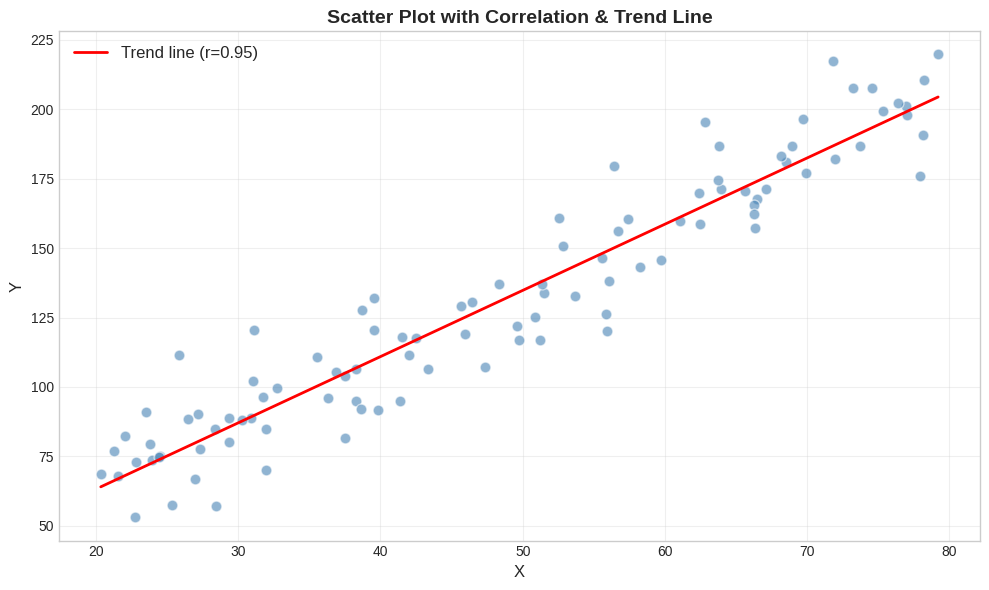

In [26]:
# Scatter plot with NumPy-generated data and trend line
np.random.seed(42)
x = np.random.uniform(20, 80, 100)
y = 2.5 * x + np.random.normal(0, 15, 100) + 10

# Calculate correlation and trend line
r = np.corrcoef(x, y)[0, 1]  # correlation coefficient
coeffs = np.polyfit(x, y, 1)  # linear fit (degree 1)
trend_x = np.linspace(x.min(), x.max(), 100)
trend_y = np.polyval(coeffs, trend_x)  # evaluate the polynomial

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color='steelblue', edgecolor='white', s=60)
plt.plot(trend_x, trend_y, color='red', linewidth=2,
         label=f'Trend line (r={r:.2f})')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Scatter Plot with Correlation & Trend Line', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Introduction to Hypothesis Testing
---

## Key Concepts: Hypothesis Testing

```
THE HYPOTHESIS TESTING FRAMEWORK:

    STEP 1: STATE HYPOTHESES
    ────────────────────────
    H0 (null):        "No effect. Any difference is random chance."
    H1 (alternative): "There IS a real effect."

    STEP 2: COLLECT DATA & COMPUTE
    ──────────────────────────────
    Calculate a test statistic (how far the data is from H0)
    Calculate a p-value (probability of this result under H0)

    STEP 3: DECIDE
    ──────────────
    p-value < 0.05  →  Reject H0. Evidence supports H1.
    p-value >= 0.05 →  Fail to reject H0. Not enough evidence.

    ┌──────────────────────────────────────────────────────────┐
    │  IMPORTANT: "fail to reject" ≠ "prove H0 is true"       │
    │  It just means we don't have enough evidence to say H0   │
    │  is false. Absence of evidence ≠ evidence of absence.    │
    └──────────────────────────────────────────────────────────┘

    COMMON p-value THRESHOLD:
    α = 0.05  (5% significance level)
```

In [28]:
# Import scipy for hypothesis testing
from scipy import stats


# pregunta: los empleados mejoraron la productividad gracias al entrenamiento impartido?

# Generate the training program data
np.random.seed(42)

# Productivity scores before training (mean ~50, std ~10)
productivity_before = np.random.normal(loc=50, scale=10, size=30)

# After training: same employees, but with some improvement
productivity_after = productivity_before + np.random.normal(loc=5, scale=3, size=30)

# The differences
differences = productivity_after - productivity_before

print("Training Program Data (30 employees):")
print(f"Before: mean = {productivity_before.mean():.2f}, std = {productivity_before.std():.2f}")
print(f"After:  mean = {productivity_after.mean():.2f}, std = {productivity_after.std():.2f}")
print(f"Diff:   mean = {differences.mean():.2f}, std = {differences.std():.2f}")

Training Program Data (30 employees):
Before: mean = 48.12, std = 8.85
After:  mean = 52.76, std = 9.52
Diff:   mean = 4.64, std = 2.75


## Running the Hypothesis Test

In [29]:
# Paired t-test: are the differences significantly different from 0?
# H0: mean difference = 0 (training had no effect)
# H1: mean difference > 0 (training improved productivity)

t_stat, p_value = stats.ttest_1samp(differences, 0)  # one-sample t-test on differences, testing against 0

print("Hypothesis Test Results:")
print(f"  Test statistic (t): {t_stat:.4f}")
print(f"  p-value:            {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"  p-value ({p_value:.6f}) < alpha ({alpha})")
    print("  REJECT H0: The training program significantly improved productivity!")
else:
    print(f"  p-value ({p_value:.6f}) >= alpha ({alpha})")
    print("  FAIL TO REJECT H0: Not enough evidence that training had an effect.")

Hypothesis Test Results:
  Test statistic (t): 9.0915
  p-value:            0.000000

  p-value (0.000000) < alpha (0.05)
  REJECT H0: The training program significantly improved productivity!


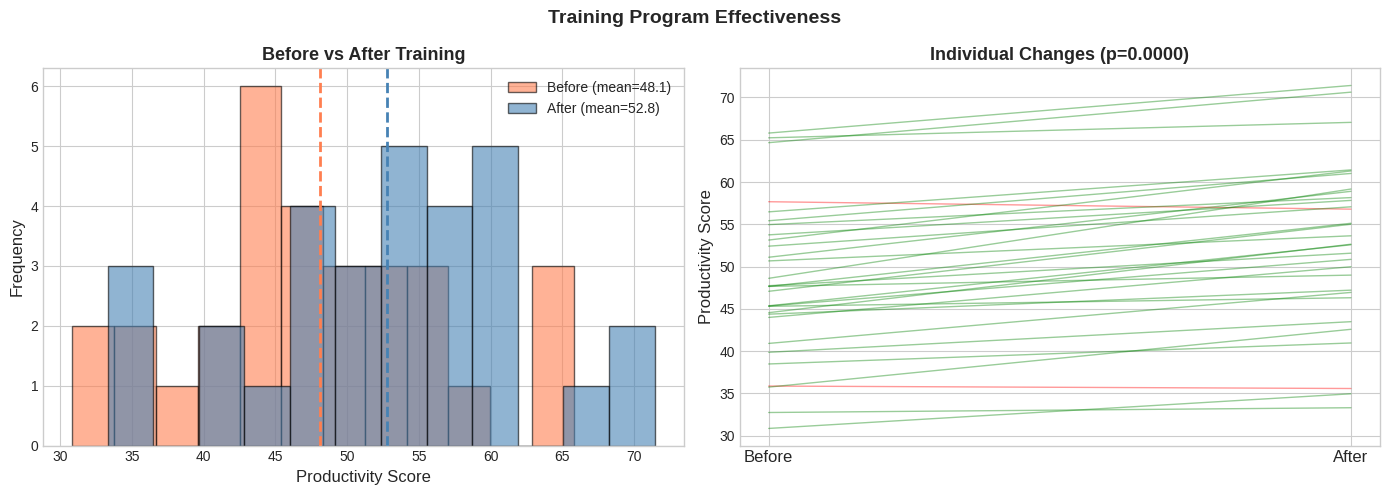

In [30]:
# Visualize: before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overlapping histograms
axes[0].hist(productivity_before, bins=12, alpha=0.6, color='coral',
             edgecolor='black', label=f'Before (mean={productivity_before.mean():.1f})')
axes[0].hist(productivity_after, bins=12, alpha=0.6, color='steelblue',
             edgecolor='black', label=f'After (mean={productivity_after.mean():.1f})')
axes[0].axvline(productivity_before.mean(), color='coral', linewidth=2, linestyle='--')
axes[0].axvline(productivity_after.mean(), color='steelblue', linewidth=2, linestyle='--')
axes[0].set_xlabel('Productivity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Before vs After Training', fontsize=13, fontweight='bold')
axes[0].legend()

# Plot 2: Individual employee changes
sorted_idx = np.argsort(differences)
for i, idx in enumerate(sorted_idx):
    color = 'green' if differences[idx] > 0 else 'red'
    axes[1].plot([0, 1], [productivity_before[idx], productivity_after[idx]],
                 color=color, alpha=0.4, linewidth=1)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Before', 'After'], fontsize=12)
axes[1].set_ylabel('Productivity Score', fontsize=12)
axes[1].set_title(f'Individual Changes (p={p_value:.4f})', fontsize=13, fontweight='bold')

plt.suptitle('Training Program Effectiveness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()